# MLP Scaling: $H$ vs $|G|$ 

Hidden neurons vs group size scaling experiments.

## Set up

In [48]:
# autoreload
%load_ext autoreload
%autoreload 2
# jupyter black formatter
%load_ext jupyter_black

import subprocess
import os
import sys

gitroot_path = subprocess.check_output(
    ["git", "rev-parse", "--show-toplevel"], universal_newlines=True
)

os.chdir(os.path.join(gitroot_path[:-1], "gagf"))
print("Working directory: ", os.getcwd())

sys_dir = os.path.dirname(os.getcwd())
sys.path.append(sys_dir)
print("Directory added to path: ", sys_dir)
sys.path.append(os.getcwd())
print("Directory added to path: ", os.getcwd())

import yaml
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
The jupyter_black extension is already loaded. To reload it, use:
  %reload_ext jupyter_black
Working directory:  /home/facosta/group-agf/gagf
Directory added to path:  /home/facosta/group-agf
Directory added to path:  /home/facosta/group-agf/gagf


## Specify experiment directory

In [49]:
# sweep_dir = "/home/facosta/group-agf/sweeps/onehot_scaling_sweep_20251215_175955"
# sweep_dir = "/home/facosta/group-agf/sweep_results/onehot_scaling_sweep_20260112_022012"
# sweep_dir = (
#     "/home/facosta/group-agf/sweep_results/smaller_scaling_sweep_20260116_175424"
# )

# sweep_dir = "/home/facosta/group-agf/sweep_results/onehot_scaling_sweep_20260216_170713"


sweep_dir = (
    "/home/facosta/group-agf/sweep_results/smaller_scaling_sweep_20260116_175424"
)
sweep_dir = Path(sweep_dir)

print(os.path.exists(sweep_dir))

True


## Helper functions

In [50]:
def load_sweep_results_grid_convergence_p_h(
    sweep_dir: str,
    k: int,
    p_values: list,
    hidden_dims: list,
    reduction_threshold: float = 0.99,
    max_p: int = None,
):
    """
    Load sweep results and compute steps to convergence for p vs hidden_dim sweep.

    Updated for experiment naming: k{k}_p{p}_h{h}
    Only loads completed experiments (checks for run_summary.yaml).

    Convergence is defined as reaching `reduction_threshold` loss reduction
    (e.g., 0.99 = 99% reduction from initial loss).

    If convergence is not reached, the grid point is set to NaN (blacked out).

    Args:
        sweep_dir: Path to the sweep directory
        k: Sequence length parameter (2, 3, or 4)
        p_values: List of p (group size) values
        hidden_dims: List of hidden dimension values
        reduction_threshold: Fraction of loss reduction to consider converged
        max_p: Maximum p value to include (filters incomplete experiments)

    Returns:
        grid: 2D array with mean steps to convergence (NaN if didn't converge)
              Shape: (len(hidden_dims), len(p_values))
        std_grid: 2D array with standard deviations across seeds
    """
    sweep_path = Path(sweep_dir)

    grid = np.full((len(hidden_dims), len(p_values)), np.nan)
    std_grid = np.full((len(hidden_dims), len(p_values)), np.nan)

    for i, h in enumerate(hidden_dims):
        for j, p in enumerate(p_values):
            # Filter by max_p if specified
            if max_p is not None and p > max_p:
                continue

            exp_name = f"k{k}_p{p}_h{h}"
            exp_dir = sweep_path / exp_name

            if not exp_dir.exists():
                continue

            # Check if experiment is completed (has run_summary.yaml)
            seed_dir = exp_dir / "seed_0"
            if not seed_dir.exists() or not (seed_dir / "run_summary.yaml").exists():
                continue  # Skip incomplete experiments

            # Collect convergence steps from all seeds
            convergence_steps = []
            for seed_dir in exp_dir.glob("seed_*"):
                loss_file = seed_dir / "train_loss_history.npy"
                if loss_file.exists():
                    loss_history = np.load(loss_file)
                    initial_loss = loss_history[0]

                    if initial_loss > 0:
                        # Compute reduction at each step
                        reductions = 1 - loss_history / initial_loss

                        # Find first step where reduction >= threshold
                        converged_mask = reductions >= reduction_threshold
                        if np.any(converged_mask):
                            step = np.argmax(converged_mask)  # First True
                            convergence_steps.append(step)
                        # else: Never converged - don't add to list

            if convergence_steps:
                grid[i, j] = np.mean(convergence_steps)
                std_grid[i, j] = (
                    np.std(convergence_steps) if len(convergence_steps) > 1 else 0.0
                )
            # else: No seeds converged - grid[i,j] remains NaN (blacked out)

    return grid, std_grid

In [51]:
def load_sweep_results_grid_final_loss_p_h(
    sweep_dir: str,
    k: int,
    p_values: list,
    hidden_dims: list,
    max_p: int = None,
):
    """
    Load sweep results and compute final training loss for p vs hidden_dim sweep.

    Updated for experiment naming: k{k}_p{p}_h{h}
    Only loads completed experiments (checks for run_summary.yaml).

    Args:
        sweep_dir: Path to the sweep directory
        k: Sequence length parameter (2, 3, or 4)
        p_values: List of p (group size) values
        hidden_dims: List of hidden dimension values
        max_p: Maximum p value to include (filters incomplete experiments)

    Returns:
        grid: 2D array with mean final training loss (NaN if experiment incomplete)
              Shape: (len(hidden_dims), len(p_values))
        std_grid: 2D array with standard deviations across seeds
    """
    sweep_path = Path(sweep_dir)

    grid = np.full((len(hidden_dims), len(p_values)), np.nan)
    std_grid = np.full((len(hidden_dims), len(p_values)), np.nan)

    for i, h in enumerate(hidden_dims):
        for j, p in enumerate(p_values):
            # Filter by max_p if specified
            if max_p is not None and p > max_p:
                continue

            exp_name = f"k{k}_p{p}_h{h}"
            exp_dir = sweep_path / exp_name

            if not exp_dir.exists():
                continue

            # Check if experiment is completed (has run_summary.yaml)
            seed_dir = exp_dir / "seed_0"
            if not seed_dir.exists() or not (seed_dir / "run_summary.yaml").exists():
                continue  # Skip incomplete experiments

            # Collect final losses from all seeds
            final_losses = []
            for seed_dir in exp_dir.glob("seed_*"):
                loss_file = seed_dir / "train_loss_history.npy"
                if loss_file.exists():
                    loss_history = np.load(loss_file)
                    if len(loss_history) > 0:
                        final_loss = loss_history[-1]  # Last value
                        final_losses.append(final_loss)

            if final_losses:
                grid[i, j] = np.mean(final_losses)
                std_grid[i, j] = np.std(final_losses) if len(final_losses) > 1 else 0.0
            # else: No seeds found - grid[i,j] remains NaN (blacked out)

    return grid, std_grid

In [52]:
def plot_theory_boundaries(
    ax_or_plt,
    k,
    p_values_filtered,
    hidden_dims,
    use_ax=False,
):
    """
    Plot all theory boundaries: H = m * 2^{k-1} * |G| for m = 1, 2, ..., k+1.

    Args:
        ax_or_plt: Either an axis object (if use_ax=True) or plt module
        k: Sequence length parameter
        p_values_filtered: List of p values to plot
        hidden_dims: List of hidden dimension values
        use_ax: If True, use ax.step instead of plt.step

    Styling:
        - m = k+1 (upper boundary): dark black, solid, thick
        - m = 1, ..., k: black, dashed
    """
    x_step = np.arange(len(p_values_filtered) + 1) - 0.5

    step_func = ax_or_plt.step if use_ax else plt.step

    for m in range(1, k + 2):  # m = 1, 2, ..., k+1
        boundary_coeff = m * (2 ** (k - 1))
        y_step = [
            min(
                len(hidden_dims) - 1,
                (
                    # Find the first H that satisfies H >= boundary_coeff * p
                    np.argmax(np.array(hidden_dims) >= boundary_coeff * p)
                    if boundary_coeff * p <= max(hidden_dims)
                    else len(hidden_dims) - 1
                ),
            )
            for p in p_values_filtered
        ]
        y_step.append(y_step[-1])  # Extend for step plot
        # Convert to edge positions (subtract 0.5 to place at bottom edge of cells)
        y_step = [y - 0.5 for y in y_step]

        # Styling: m=k+1 is solid black thick, all others are dashed black
        if m == k + 1:
            color = "black"
            linewidth = 3
            linestyle = "-"
            label = f"$m={m}$: $H$ ≥ ${m} \\cdot 2^{{k-1}} |G|$"
        else:
            color = "black"
            linewidth = 2
            linestyle = "--"
            if m == 1:
                label = f"$m=1$: $H$ ≥ $2^{{k-1}} |G|$"
            else:
                label = f"$m={m}$: $H$ ≥ ${m} \\cdot 2^{{k-1}} |G|$"

        step_func(
            x_step,
            y_step,
            where="post",
            color=color,
            linewidth=linewidth,
            linestyle=linestyle,
            label=label,
        )

In [53]:
def load_sweep_results_grid_initial_loss_p_h(
    sweep_dir: str,
    k: int,
    p_values: list,
    hidden_dims: list,
    max_p: int = None,
):
    """
    Load sweep results and compute initial training loss for p vs hidden_dim sweep.

    Args:
        sweep_dir: Path to the sweep directory
        k: Sequence length parameter (2, 3, or 4)
        p_values: List of p (group size) values
        hidden_dims: List of hidden dimension values
        max_p: Maximum p value to include (filters incomplete experiments)

    Returns:
        grid: 2D array with mean initial training loss (NaN if experiment incomplete)
              Shape: (len(hidden_dims), len(p_values))
        std_grid: 2D array with standard deviations across seeds
    """
    sweep_path = Path(sweep_dir)

    grid = np.full((len(hidden_dims), len(p_values)), np.nan)
    std_grid = np.full((len(hidden_dims), len(p_values)), np.nan)

    for i, h in enumerate(hidden_dims):
        for j, p in enumerate(p_values):
            # Filter by max_p if specified
            if max_p is not None and p > max_p:
                continue

            exp_name = f"k{k}_p{p}_h{h}"
            exp_dir = sweep_path / exp_name

            if not exp_dir.exists():
                continue

            # Check if experiment is completed (has run_summary.yaml)
            seed_dir = exp_dir / "seed_0"
            if not seed_dir.exists() or not (seed_dir / "run_summary.yaml").exists():
                continue  # Skip incomplete experiments

            # Collect initial losses from all seeds
            initial_losses = []
            for seed_dir in exp_dir.glob("seed_*"):
                loss_file = seed_dir / "train_loss_history.npy"
                if loss_file.exists():
                    loss_history = np.load(loss_file)
                    if len(loss_history) > 0 and loss_history[0] > 0:
                        initial_losses.append(loss_history[0])

            if initial_losses:
                grid[i, j] = np.mean(initial_losses)
                std_grid[i, j] = (
                    np.std(initial_losses) if len(initial_losses) > 1 else 0.0
                )
            # else: No seeds found - grid[i,j] remains NaN (blacked out)

    return grid, std_grid

In [54]:
def load_initial_losses_by_p(
    sweep_dir: str,
    k: int,
    hidden_dim: int,
    p_values: list,
):
    """
    Load initial training losses for different group sizes (p) with fixed k and hidden_dim.

    Args:
        sweep_dir: Path to the sweep directory
        k: Sequence length parameter (fixed)
        hidden_dim: Hidden dimension (fixed)
        p_values: List of p (group size) values

    Returns:
        initial_losses: Dictionary mapping p -> list of initial losses (one per seed)
    """
    sweep_path = Path(sweep_dir)

    initial_losses = {}

    for p in p_values:
        exp_name = f"k{k}_p{p}_h{hidden_dim}"
        exp_dir = sweep_path / exp_name

        if not exp_dir.exists():
            continue

        # Check if experiment is completed
        seed_dir = exp_dir / "seed_0"
        if not seed_dir.exists() or not (seed_dir / "run_summary.yaml").exists():
            continue  # Skip incomplete experiments

        # Collect initial losses from all seeds
        losses = []
        for seed_dir in exp_dir.glob("seed_*"):
            loss_file = seed_dir / "train_loss_history.npy"
            if loss_file.exists():
                loss_history = np.load(loss_file)
                if len(loss_history) > 0 and loss_history[0] > 0:
                    losses.append(loss_history[0])

        if losses:
            initial_losses[p] = losses

    return initial_losses

In [55]:
def load_training_loss_curves_p(
    sweep_dir: str,
    k: int,
    hidden_dim: int,
    p_values: list,
):
    """
    Load training loss histories for different group sizes (p) with fixed k and hidden_dim.

    Args:
        sweep_dir: Path to the sweep directory
        k: Sequence length parameter (fixed)
        hidden_dim: Hidden dimension (fixed)
        p_values: List of p (group size) values to plot

    Returns:
        curves: Dictionary mapping p -> list of loss histories (one per seed)
                Each loss history is a numpy array
    """
    sweep_path = Path(sweep_dir)

    curves = {}

    for p in p_values:
        exp_name = f"k{k}_p{p}_h{hidden_dim}"
        exp_dir = sweep_path / exp_name

        if not exp_dir.exists():
            continue

        # Check if experiment is completed
        seed_dir = exp_dir / "seed_0"
        if not seed_dir.exists() or not (seed_dir / "run_summary.yaml").exists():
            continue  # Skip incomplete experiments

        # Collect loss histories from all seeds
        loss_histories = []
        for seed_dir in exp_dir.glob("seed_*"):
            loss_file = seed_dir / "train_loss_history.npy"
            if loss_file.exists():
                loss_history = np.load(loss_file)
                if len(loss_history) > 0:
                    loss_histories.append(loss_history)

        if loss_histories:
            curves[p] = loss_histories

    return curves

## Sweep parameter values

In [56]:
# # Define parameter values from the sweep config
# # Filter to p <= 55 for completed experiments
# p_values = [
#     5,
#     10,
#     15,
#     20,
#     25,
#     30,
#     35,
#     40,
#     45,
#     50,
#     55,
#     60,
#     65,
#     70,
# ]
#     75,
#     80,
#     85,
#     90,
#     95,
#     100,
# ]
# hidden_dims = [
#     80,
#     160,
#     240,
#     320,
#     400,
#     480,
#     560,
#     640,
#     720,
#     800,
#     880,
#     960,
#     1040,
#     1120,
#     1200,
#     1280,
#     1360,
#     1440,
#     1520,
#     1600,
# ]
p_values = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]
hidden_dims = [
    5,
    10,
    15,
    20,
    25,
    30,
    35,
    40,
    45,
    50,
    55,
    60,
    65,
    70,
    75,
    80,
    85,
    90,
    95,
    100,
]
k_values = [2, 3]  # , 3]  # , 4]  # Different k values to plot separately

## Final Training Loss Heatmap

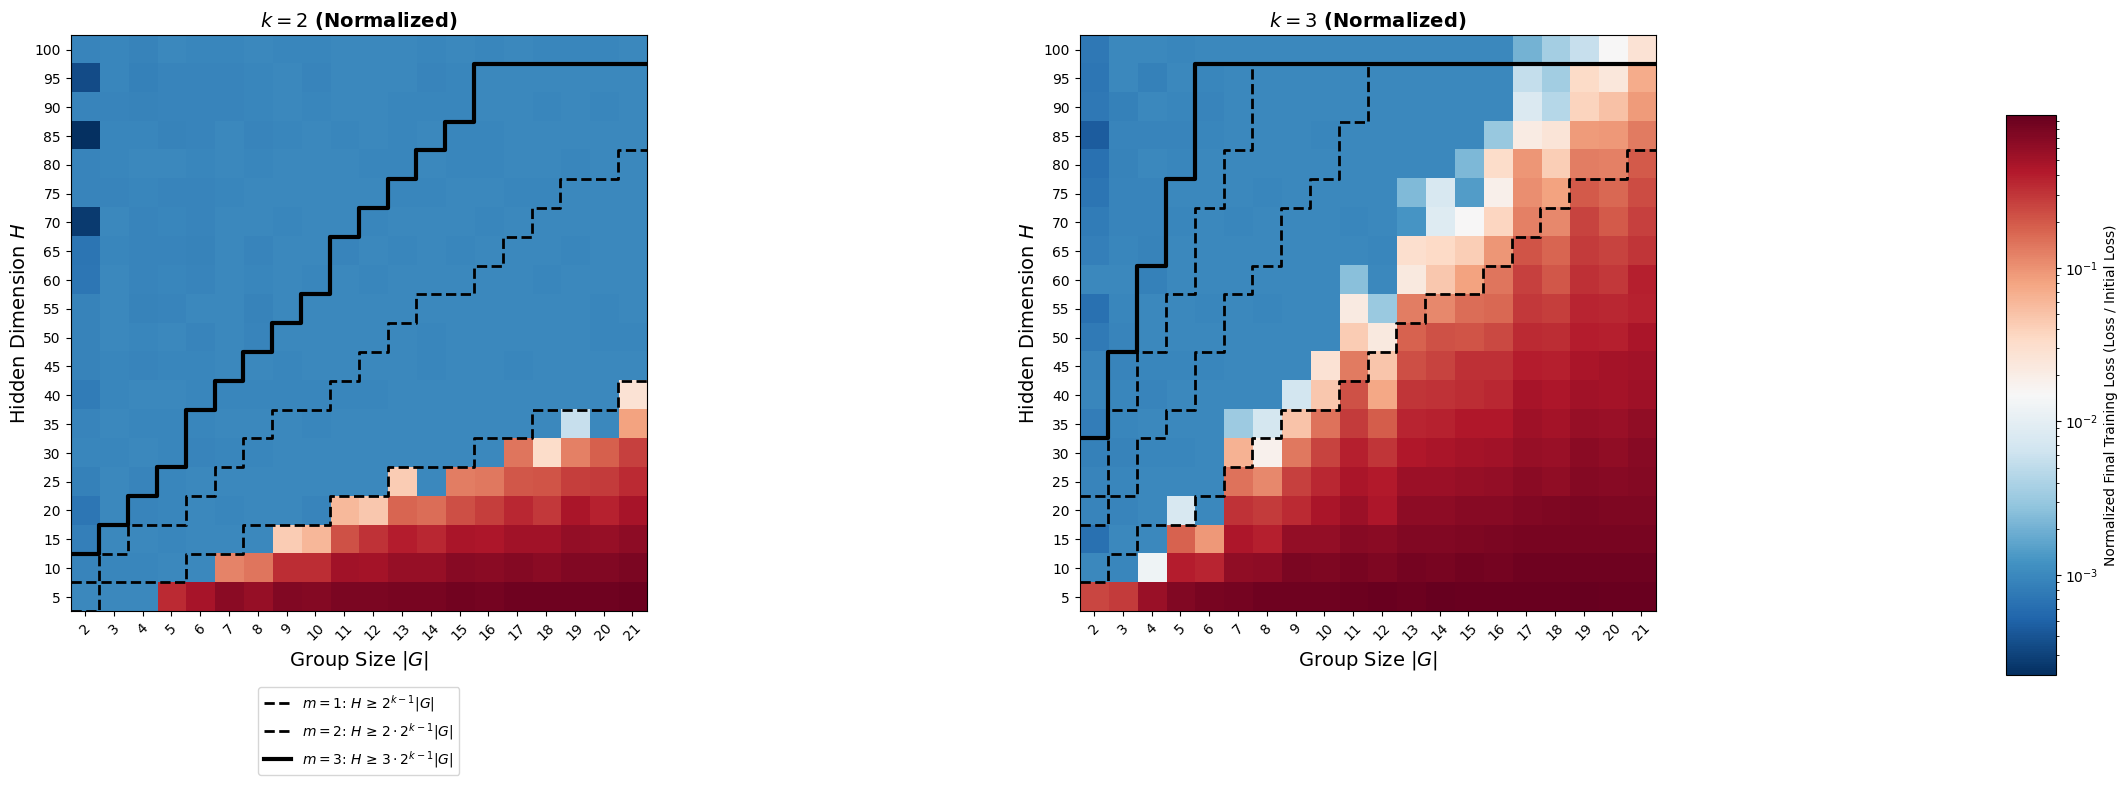

In [57]:
from matplotlib.colors import LogNorm

# Load final training loss data for each k value separately
max_p = 100
normalize_init_loss = True  # Set to True to normalize by initial loss

# Filter p values - only show p <= max_p
p_values_filtered = [p for p in p_values if p <= max_p]

# First, load all data to find global min/max for shared colorbar
all_loss_grids = {}
for k in k_values:
    loss_grid, loss_std = load_sweep_results_grid_final_loss_p_h(
        sweep_dir,
        k,
        p_values,
        hidden_dims,
        max_p=max_p,
    )

    # Normalize by initial loss if requested
    if normalize_init_loss:
        init_loss_grid, _ = load_sweep_results_grid_initial_loss_p_h(
            sweep_dir,
            k,
            p_values,
            hidden_dims,
            max_p=max_p,
        )
        # Normalize: divide final loss by initial loss (element-wise)
        # Only normalize where both are non-NaN
        mask = ~(np.isnan(loss_grid) | np.isnan(init_loss_grid))
        loss_grid_normalized = loss_grid.copy()
        loss_grid_normalized[mask] = loss_grid[mask] / init_loss_grid[mask]
        loss_grid = loss_grid_normalized

    all_loss_grids[k] = loss_grid[:, : len(p_values_filtered)]

# Find global min/max across all k values (ignoring NaN)
all_valid_values = np.concatenate(
    [grid[~np.isnan(grid)].flatten() for grid in all_loss_grids.values()]
)
vmin, vmax = np.min(all_valid_values), np.max(all_valid_values)
norm = LogNorm(vmin=vmin, vmax=vmax)

# Create subplots: one for each k value, with extra space for colorbar
fig, axes = plt.subplots(1, len(k_values), figsize=(12 * len(k_values) + 1, 8))
if len(k_values) == 1:
    axes = [axes]  # Make it iterable

# cmap = plt.cm.viridis_r.copy()
cmap = plt.cm.RdBu_r.copy()
# cmap.set_bad(color="black")

for idx, k in enumerate(k_values):
    ax = axes[idx]
    loss_grid = all_loss_grids[k]

    im = ax.imshow(
        loss_grid,
        aspect="equal",
        cmap=cmap,
        norm=norm,
    )

    ax.set_xlabel("Group Size $|G|$", fontsize=14)
    ax.set_ylabel("Hidden Dimension $H$", fontsize=14)
    ax.set_xticks(range(len(p_values_filtered)))
    ax.set_xticklabels(p_values_filtered, rotation=45, ha="center")

    # Set y-axis ticks (hidden dimensions)
    ax.set_yticks(range(len(hidden_dims)))
    ax.set_yticklabels(hidden_dims)
    ax.invert_yaxis()

    # Theory boundaries: H = m * 2^{k-1} * |G| for m = 1, 2, ..., k+1
    plot_theory_boundaries(
        ax,
        k,
        p_values_filtered,
        hidden_dims,
        use_ax=True,
    )

    # Place legend outside the plot area (only for the first subplot)
    if idx == 0:
        ax.legend(
            loc="upper center", bbox_to_anchor=(0.5, -0.12), fontsize=10, frameon=True
        )
    else:
        ax.legend().set_visible(False)

    title_suffix = " (Normalized)" if normalize_init_loss else ""
    ax.set_title(
        f"$k={k}${title_suffix}",
        fontsize=14,
        fontweight="bold",
    )

# Add a single shared colorbar on the right side
colorbar_label = (
    "Normalized Final Training Loss (Loss / Initial Loss)"
    if normalize_init_loss
    else "Final Training Loss"
)

# Adjust layout first, then add colorbar
fig.tight_layout()
fig.subplots_adjust(right=0.88)  # Make room for colorbar on the right

# Add colorbar in dedicated space on the right
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
fig.colorbar(im, cax=cbar_ax, label=colorbar_label)

# fig.suptitle(
#     "Final Training Loss: Group Size $|G|$ vs Hidden Dimension $H$",
#     fontsize=16,
#     fontweight="bold",
#     y=0.98,
# )


# fig.savefig("final_training_loss.pdf", bbox_inches="tight", dpi=300)

plt.show()

In [67]:
import yaml
from pathlib import Path

sweep_dir = Path(sweep_dir)
times = []
for summary in sweep_dir.glob("*/seed_0/run_summary.yaml"):
    with open(summary) as f:
        data = yaml.safe_load(f)
    times.append((data["experiment_name"], data["training_time"]))

# get the sum of the training times
total_time = sum([t for _, t in times])
mean_time = np.mean([t for _, t in times])
print(f"Total training time: {total_time/3600:.1f} GPU hours")
print(f"Mean training time: {mean_time/3600:.1f} GPU hours")
print(f"Median training time: {np.median([t for _, t in times])/3600:.1f} GPU hours")

# # Sort by time
# for name, t in sorted(times, key=lambda x: x[1], reverse=True):
#     print(f"{name}: {t/60:.1f} min")

Total training time: 284.7 GPU hours
Mean training time: 0.4 GPU hours
Median training time: 0.0 GPU hours


## Training Loss Curves by Group Size

In [62]:
# Plot training loss curves for different group sizes
# Specify the hidden dimension to use
hidden_dim = 640  # Change this to plot different hidden dimensions

# Use all available p values (or filter as needed)
p_values_to_plot = [p for p in p_values if p <= 100]  # Adjust max_p as needed

# Create separate plots for each k value
for k in k_values:
    # Load training loss curves for different p values
    curves = load_training_loss_curves_p(
        sweep_dir,
        k,
        hidden_dim,
        p_values_to_plot,
    )

    if not curves:
        print(f"No data found for k={k}, H={hidden_dim}")
        continue

    # Create plot
    plt.figure(figsize=(14, 8))

    # Plot each group size as a separate curve
    # Use a colormap to distinguish different p values
    colors = plt.cm.plasma(np.linspace(0, 1, len(curves)))

    for i, (p, loss_histories) in enumerate(sorted(curves.items())):
        # Normalize each loss history by its initial value
        normalized_histories = []
        for hist in loss_histories:
            if len(hist) > 0 and hist[0] > 0:
                # Normalize by initial loss
                normalized = hist / hist[0]
                normalized_histories.append(normalized)
            else:
                # Skip invalid histories
                continue

        if not normalized_histories:
            continue

        # Find the maximum length to align all curves
        max_len = max(len(hist) for hist in normalized_histories)

        # Pad shorter histories with NaN
        aligned_histories = []
        for hist in normalized_histories:
            if len(hist) < max_len:
                padded = np.full(max_len, np.nan)
                padded[: len(hist)] = hist
                aligned_histories.append(padded)
            else:
                aligned_histories.append(hist)

        aligned_histories = np.array(aligned_histories)

        # Compute mean and std across seeds
        mean_loss = np.nanmean(aligned_histories, axis=0)
        std_loss = np.nanstd(aligned_histories, axis=0)

        # Create step array (1-indexed for log scale)
        steps = np.arange(1, len(mean_loss) + 1)

        # Plot mean curve
        plt.loglog(
            steps,
            mean_loss,
            color=colors[i],
            linewidth=2,
            label=f"$|G|={p}$",
        )

        # Plot shaded error region (optional, can be commented out if too cluttered)
        # plt.fill_between(
        #     steps,
        #     mean_loss - std_loss,
        #     mean_loss + std_loss,
        #     color=colors[i],
        #     alpha=0.2,
        # )

    plt.xlabel("Training Steps", fontsize=14)
    plt.ylabel("Normalized Training Loss (Loss / Initial Loss)", fontsize=14)
    plt.title(
        f"Normalized Training Loss Curves: Group Size $|G|$ vs Steps\n($k={k}$, $H={hidden_dim}$)",
        fontsize=14,
        fontweight="bold",
    )
    plt.legend(loc="best", fontsize=10, ncol=1, bbox_to_anchor=(1.05, 1))
    plt.grid(True, alpha=0.3, which="both")
    plt.tight_layout()

    # plt.savefig(
    #     f"training_loss_curves_k{k}_H{hidden_dim}.pdf", bbox_inches="tight", dpi=300
    # )
    plt.show()

No data found for k=2, H=640
No data found for k=3, H=640


## Plot steps to convergence grid

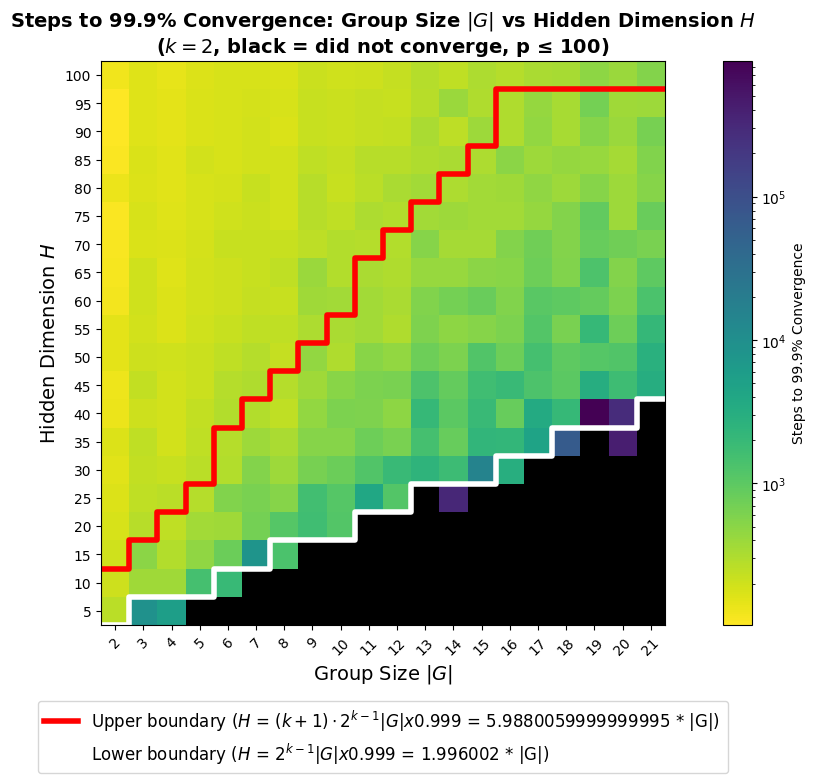

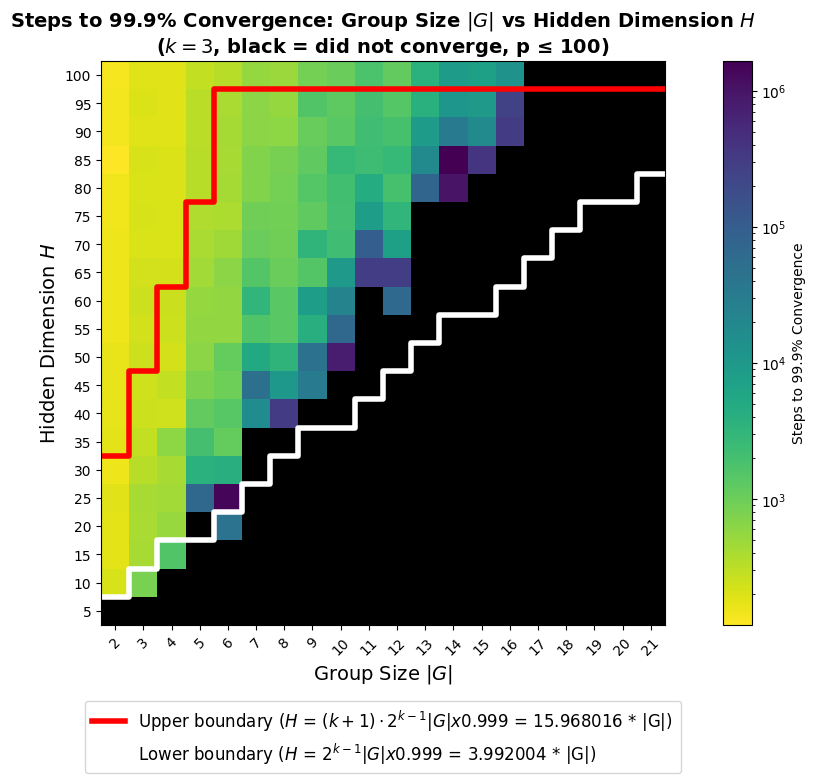

In [68]:
# Load convergence data for each k value separately
reduction_threshold = 0.999
max_p = 100  # Only visualize completed experiments (p <= 55)

from matplotlib.colors import LogNorm

# Create separate plots for each k value
for k in k_values:
    conv_grid, conv_std = load_sweep_results_grid_convergence_p_h(
        sweep_dir,
        k,
        p_values,
        hidden_dims,
        reduction_threshold=reduction_threshold,
        max_p=max_p,
    )

    # Filter p values - only show p <= max_p
    p_values_filtered = [p for p in p_values if p <= max_p]

    # Plot convergence heatmap: p (group size) vs hidden_dim
    plt.figure(figsize=(12, 8))
    cmap = plt.cm.viridis_r.copy()
    cmap.set_bad(color="black")
    # Set extent to align cells with tick positions
    # extent: [left, right, bottom, top] in data coordinates
    plt.imshow(
        conv_grid[:, : len(p_values_filtered)],
        aspect="equal",
        cmap=cmap,
        norm=LogNorm(),
    )

    plt.xlabel("Group Size $|G|$", fontsize=14)
    plt.ylabel("Hidden Dimension $H$", fontsize=14)
    plt.xticks(
        range(len(p_values_filtered)), p_values_filtered, rotation=45, ha="center"
    )

    # Set y-axis ticks (hidden dimensions)
    plt.yticks(range(len(hidden_dims)), hidden_dims)
    plt.gca().invert_yaxis()

    # Theory boundaries
    x_step = np.arange(len(p_values_filtered) + 1) - 0.5

    # Upper boundary: H = (k+1)*2^{k-1} * |G|
    upper_boundary_coeff = (k + 1) * (2 ** (k - 1)) * reduction_threshold
    y_step_upper = [
        min(
            len(hidden_dims) - 1,
            (
                # Find the first H that satisfies H >= upper_boundary_coeff * p
                np.argmax(np.array(hidden_dims) >= upper_boundary_coeff * p)
                if upper_boundary_coeff * p <= max(hidden_dims)
                else len(hidden_dims) - 1
            ),
        )
        for p in p_values_filtered
    ]
    y_step_upper.append(y_step_upper[-1])  # Extend for step plot
    # Convert to edge positions (subtract 0.5 to place at bottom edge of cells)
    y_step_upper = [y - 0.5 for y in y_step_upper]

    # Lower boundary: H = 2^{k-1} * |G|
    lower_boundary_coeff = 2 ** (k - 1) * reduction_threshold
    y_step_lower = [
        min(
            len(hidden_dims) - 1,
            (
                # Find the first H that satisfies H >= lower_boundary_coeff * p
                np.argmax(np.array(hidden_dims) >= lower_boundary_coeff * p)
                if lower_boundary_coeff * p <= max(hidden_dims)
                else len(hidden_dims) - 1
            ),
        )
        for p in p_values_filtered
    ]
    y_step_lower.append(y_step_lower[-1])  # Extend for step plot
    # Convert to edge positions (subtract 0.5 to place at bottom edge of cells)
    y_step_lower = [y - 0.5 for y in y_step_lower]

    plt.step(
        x_step,
        y_step_upper,
        where="post",
        color="red",
        linewidth=4,
        linestyle="-",
        label=f"Upper boundary ($H$ = $(k+1) \\cdot 2^{{k-1}} |G| x {reduction_threshold}$ = {upper_boundary_coeff * reduction_threshold} * |G|) ",
    )

    plt.step(
        x_step,
        y_step_lower,
        where="post",
        color="white",
        linewidth=4,
        linestyle="-",
        label=f"Lower boundary ($H$ = $2^{{k-1}} |G| x {reduction_threshold}$ = {lower_boundary_coeff * reduction_threshold} * |G|) ",
    )

    # Place legend outside the plot area
    plt.legend(
        loc="upper center", bbox_to_anchor=(0.5, -0.12), fontsize=12, frameon=True
    )

    plt.colorbar(label=f"Steps to {reduction_threshold*100}% Convergence")
    plt.title(
        f"Steps to {reduction_threshold*100}% Convergence: Group Size $|G|$ vs Hidden Dimension $H$\n($k={k}$, black = did not converge, p ≤ {max_p})",
        fontsize=14,
        fontweight="bold",
    )
    plt.tight_layout()
    plt.show()

## Initial train loss vs group size

In [ ]:
# Plot initial training loss vs group size
# Specify the hidden dimension to use
hidden_dim = 160  # Change this to plot different hidden dimensions

# Use all available p values (or filter as needed)
p_values_to_plot = [p for p in p_values if p <= 100]  # Adjust max_p as needed

# Create separate plots for each k value
for k in k_values:
    # Load initial losses for different p values
    initial_losses = load_initial_losses_by_p(
        sweep_dir,
        k,
        hidden_dim,
        p_values_to_plot,
    )

    if not initial_losses:
        print(f"No data found for k={k}, H={hidden_dim}")
        continue

    # Create plot
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Sort p values
    sorted_p = sorted(initial_losses.keys())

    # Compute mean and std for each p
    mean_losses = []
    std_losses = []
    p_list = []

    for p in sorted_p:
        losses = initial_losses[p]
        mean_losses.append(np.mean(losses))
        std_losses.append(np.std(losses))
        p_list.append(p)

    p_array = np.array(p_list)
    mean_array = np.array(mean_losses)
    std_array = np.array(std_losses)

    # Plot initial loss vs |G|
    ax1.errorbar(
        p_array,
        mean_array,
        yerr=std_array,
        fmt="o-",
        color="blue",
        linewidth=2,
        markersize=8,
        capsize=5,
        label="Initial Training Loss",
    )
    ax1.set_xlabel("Group Size $|G|$", fontsize=14)
    ax1.set_ylabel("Initial Training Loss", fontsize=14, color="blue")
    ax1.tick_params(axis="y", labelcolor="blue")
    ax1.set_xscale("log")
    ax1.set_yscale("log")
    ax1.grid(True, alpha=0.3, which="both")

    # Create second y-axis for 1/|G|
    ax2 = ax1.twinx()
    ax2.plot(
        p_array,
        1.0 / p_array,
        "r--",
        linewidth=2,
        label="$1/|G|$",
    )
    ax2.set_ylabel("$1/|G|$", fontsize=14, color="red")
    ax2.tick_params(axis="y", labelcolor="red")
    ax2.set_yscale("log")

    # Combine legends
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="best", fontsize=12)

    plt.title(
        f"Initial Training Loss vs Group Size $|G|$\n($k={k}$, $H={hidden_dim}$)",
        fontsize=14,
        fontweight="bold",
    )
    plt.tight_layout()
    plt.show()

## Training Instability

In [ ]:
def load_sweep_results_grid_spikiness_p_h(
    sweep_dir: str, k: int, p_values: list, hidden_dims: list, max_p: int = None
):
    """
    Compute fraction of training steps where loss increased (instability) for p vs h sweeps.

    Updated for experiment naming: k{k}_p{p}_h{h}
    Only loads completed experiments (checks for run_summary.yaml).

    Args:
        sweep_dir: Path to the sweep directory
        k: Sequence length parameter (2, 3, or 4)
        p_values: List of p (group size) values
        hidden_dims: List of hidden dimension values
        max_p: Maximum p value to include (filters incomplete experiments)

    Returns:
        grid: 2D array with mean frac_upward across seeds
              Shape: (len(hidden_dims), len(p_values))
        std_grid: 2D array with standard deviations
    """
    sweep_path = Path(sweep_dir)

    grid = np.full((len(hidden_dims), len(p_values)), np.nan)
    std_grid = np.full((len(hidden_dims), len(p_values)), np.nan)

    for i, h in enumerate(hidden_dims):
        for j, p in enumerate(p_values):
            # Filter by max_p if specified
            if max_p is not None and p > max_p:
                continue

            exp_name = f"k{k}_p{p}_h{h}"
            exp_dir = sweep_path / exp_name

            if not exp_dir.exists():
                continue

            # Check if experiment is completed
            seed_dir = exp_dir / "seed_0"
            if not seed_dir.exists() or not (seed_dir / "run_summary.yaml").exists():
                continue  # Skip incomplete experiments

            frac_upwards = []
            for seed_dir in exp_dir.glob("seed_*"):
                loss_file = seed_dir / "train_loss_history.npy"
                if loss_file.exists():
                    loss_history = np.load(loss_file)
                    log_loss = np.log10(loss_history + 1e-10)
                    log_changes = np.diff(log_loss)

                    # Fraction of steps where loss went UP
                    frac_upward = np.sum(log_changes > 0) / len(log_changes)
                    frac_upwards.append(frac_upward)

            if frac_upwards:
                grid[i, j] = np.mean(frac_upwards)
                std_grid[i, j] = np.std(frac_upwards) if len(frac_upwards) > 1 else 0.0

    return grid, std_grid

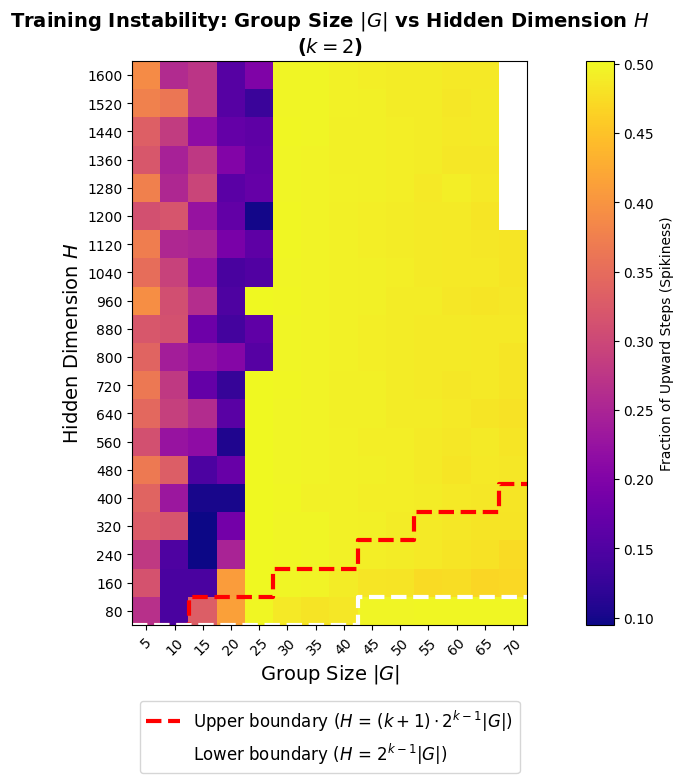

In [ ]:
# Load spikiness data for each k value separately
max_p = 100  # Only visualize completed experiments

# Create separate plots for each k value
for k in k_values:
    spike_grid_p, spike_std_p = load_sweep_results_grid_spikiness_p_h(
        sweep_dir, k, p_values, hidden_dims, max_p=max_p
    )

    p_values_filtered = [p for p in p_values if p <= max_p]

    # Plot
    plt.figure(figsize=(12, 8))
    # Set extent to align cells with tick positions
    plt.imshow(
        spike_grid_p[:, : len(p_values_filtered)],
        aspect="equal",
        cmap="plasma",
        extent=[-0.5, len(p_values_filtered) - 0.5, len(hidden_dims) - 0.5, -0.5],
    )
    plt.xlabel("Group Size $|G|$", fontsize=14)
    plt.ylabel("Hidden Dimension $H$", fontsize=14)
    plt.xticks(
        range(len(p_values_filtered)), p_values_filtered, rotation=45, ha="center"
    )
    plt.yticks(range(len(hidden_dims)), hidden_dims)
    plt.gca().invert_yaxis()

    # Theory boundaries
    x_step = np.arange(len(p_values_filtered) + 1) - 0.5

    # Upper boundary: H = (k+1)*2^{k-1} * |G|
    upper_boundary_coeff = (k + 1) * (2 ** (k - 1))
    y_step_upper = [
        min(
            len(hidden_dims) - 1,
            (
                np.argmax(np.array(hidden_dims) >= upper_boundary_coeff * p)
                if upper_boundary_coeff * p <= max(hidden_dims)
                else len(hidden_dims) - 1
            ),
        )
        for p in p_values_filtered
    ]
    y_step_upper.append(y_step_upper[-1])
    # Convert to edge positions (subtract 0.5 to place at bottom edge of cells)
    y_step_upper = [y - 0.5 for y in y_step_upper]

    # Lower boundary: H = 2^{k-1} * |G|
    lower_boundary_coeff = 2 ** (k - 1)
    y_step_lower = [
        min(
            len(hidden_dims) - 1,
            (
                np.argmax(np.array(hidden_dims) >= lower_boundary_coeff * p)
                if lower_boundary_coeff * p <= max(hidden_dims)
                else len(hidden_dims) - 1
            ),
        )
        for p in p_values_filtered
    ]
    y_step_lower.append(y_step_lower[-1])
    # Convert to edge positions (subtract 0.5 to place at bottom edge of cells)
    y_step_lower = [y - 0.5 for y in y_step_lower]

    plt.step(
        x_step,
        y_step_upper,
        where="post",
        color="red",
        linewidth=3,
        linestyle="--",
        label=f"Upper boundary ($H$ = $(k+1) \\cdot 2^{{k-1}} |G|$)",
    )

    plt.step(
        x_step,
        y_step_lower,
        where="post",
        color="white",
        linewidth=3,
        linestyle="--",
        label=f"Lower boundary ($H$ = $2^{{k-1}} |G|$)",
    )

    plt.legend(
        loc="upper center", bbox_to_anchor=(0.5, -0.12), fontsize=12, frameon=True
    )

    plt.colorbar(label="Fraction of Upward Steps (Spikiness)")
    plt.title(
        f"Training Instability: Group Size $|G|$ vs Hidden Dimension $H$\n($k={k}$)",
        fontsize=14,
        fontweight="bold",
    )
    plt.tight_layout()
    plt.show()